# 03. Эксперименты и улучшение моделей
Обучаем несколько моделей, подбираем гиперпараметры, анализируем важность признаков.
Формируем таблицу экспериментов и выбираем лучшую модель.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Настройка пути к корню проекта
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.modeling import (
    load_processed_data,
    get_models,
    evaluate_models_extended,
    hyperparameter_tuning,
    plot_feature_importance,
    save_model
)

sns.set_style('whitegrid')
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv


### Загрузка данных

In [3]:
X_train, X_test, y_train, y_test = load_processed_data()

Данные загружены: train=(8000, 30), test=(2000, 30)


### Обучение и сравнение всех моделей

In [6]:
# Получаем словарь моделей с параметрами по умолчанию
models = get_models()

# Обучаем все модели
for name, model in models.items():
    print(f'Обучение: {name}...')
    model.fit(X_train, y_train)

print('Все модели обучены.')

Обучение: Logistic Regression...
Обучение: KNN...
Обучение: Decision Tree...
Обучение: Random Forest...
Обучение: XGBoost...
Обучение: Linear SVC...
Все модели обучены.


In [7]:
# Расширенная оценка
results_df = evaluate_models_extended(models, X_test, y_test)
results_df.round(4)


--- Logistic Regression ---
              precision    recall  f1-score   support

          No       0.80      0.52      0.63      1601
         Yes       0.20      0.48      0.28       399

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.51      0.56      2000

ROC-AUC: 0.5055, PR-AUC: 0.2074

--- KNN ---
              precision    recall  f1-score   support

          No       0.80      0.94      0.86      1601
         Yes       0.18      0.05      0.08       399

    accuracy                           0.76      2000
   macro avg       0.49      0.50      0.47      2000
weighted avg       0.68      0.76      0.71      2000

ROC-AUC: 0.4847, PR-AUC: 0.1959

--- Decision Tree ---
              precision    recall  f1-score   support

          No       0.80      0.81      0.81      1601
         Yes       0.21      0.21      0.21       399

    accuracy                           0.69      2000

c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted s


--- Linear SVC ---
              precision    recall  f1-score   support

          No       0.80      0.49      0.61      1601
         Yes       0.20      0.52      0.29       399

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.45      2000
weighted avg       0.68      0.50      0.55      2000

ROC-AUC: 0.4918, PR-AUC: 0.1926


,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC
0,Logistic Regression,0.5140,0.2013,0.4837,0.2842,0.5055,0.2074
1,KNN,0.7645,0.1842,0.0526,0.0819,0.4847,0.1959
2,Decision Tree,0.6895,0.2139,0.2080,0.2109,0.5088,0.2025
3,Random Forest,0.8005,0.0000,0.0000,0.0000,0.4989,0.1991
4,XGBoost,0.7245,0.2226,0.1529,0.1813,0.5109,0.2133
5,Linear SVC,0.4970,0.2022,0.5163,0.2906,0.4918,0.1926


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_22512\1308624430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 (Yes)', data=results_df, palette='viridis')


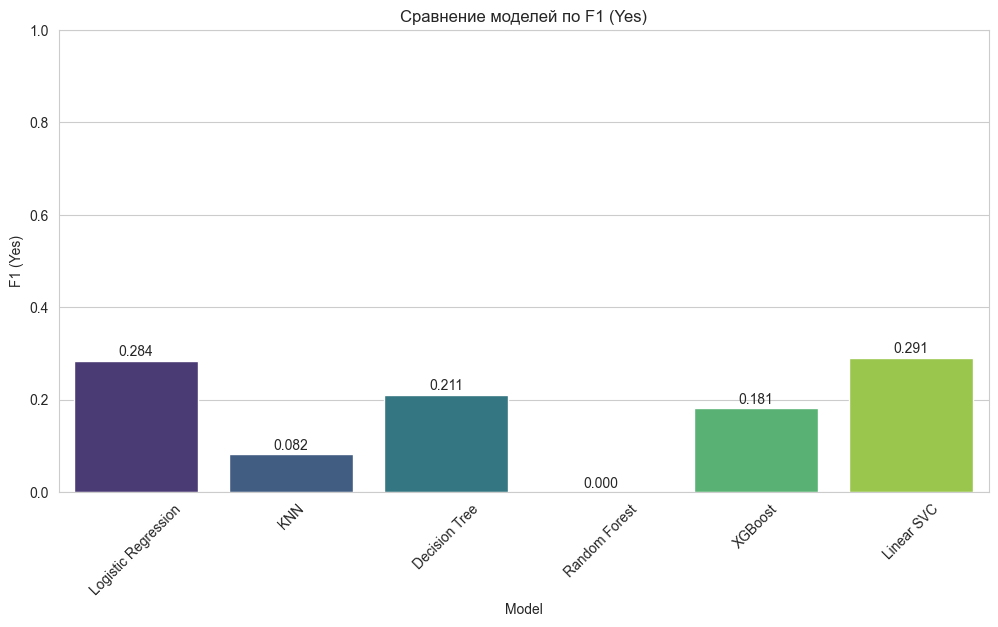

In [8]:
# Визуализация сравнения F1 для класса Yes
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1 (Yes)', data=results_df, palette='viridis')
plt.ylim(0, 1)
plt.title('Сравнение моделей по F1 (Yes)')
plt.xticks(rotation=45)
for i, row in results_df.iterrows():
    plt.text(i, row['F1 (Yes)'] + 0.01, f"{row['F1 (Yes)']:.3f}", ha='center')
plt.show()

### Подбор гиперпараметров для лучших моделей
Выбираем топ-2 модели по F1 (Yes) и улучшаем их.

In [23]:
# Определим две лучшие модели по F1
best_models_f1 = results_df.sort_values('F1 (Yes)', ascending=False).head(2)['Model'].values
print('Лучшие модели для тюнинга:', best_models_f1)

Лучшие модели для тюнинга: <StringArray>
['Linear SVC', 'Logistic Regression']
Length: 2, dtype: str


In [24]:
# Параметры для подбора
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1]
    }
}

tuned_models = {}
for model_name in best_models_f1:
    if model_name in param_grids:
        print(f'\n=== Тюнинг {model_name} ===')
        base_model = models[model_name]
        best_model, _ = hyperparameter_tuning(
            base_model, param_grids[model_name], X_train, y_train, cv=3, scoring='f1'
        )
        tuned_models[model_name + ' (tuned)'] = best_model
    else:
        print(f'Для {model_name} нет сетки параметров, пропускаем.')

print('\nТюнинг завершён.')

Для Linear SVC нет сетки параметров, пропускаем.
Для Logistic Regression нет сетки параметров, пропускаем.

Тюнинг завершён.


In [25]:
# Оцениваем настроенные модели
if tuned_models:
    tuned_results = evaluate_models_extended(tuned_models, X_test, y_test)
    print('\nРезультаты после тюнинга:')
    display(tuned_results.round(4))

### Объединение всех результатов в одну таблицу

In [26]:
# Добавляем колонку с типом эксперимента
results_df['Experiment'] = 'Default'
if tuned_models:
    tuned_results['Experiment'] = 'Tuned'
    final_table = pd.concat([results_df, tuned_results], ignore_index=True)
else:
    final_table = results_df

print('\nИтоговая таблица экспериментов:')
final_table[['Experiment', 'Model', 'Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'F1 (Yes)', 'ROC-AUC', 'PR-AUC']].round(4)


Итоговая таблица экспериментов:


,Experiment,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC
0,Default,Logistic Regression,0.5140,0.2013,0.4837,0.2842,0.5055,0.2074
1,Default,KNN,0.7645,0.1842,0.0526,0.0819,0.4847,0.1959
2,Default,Decision Tree,0.6895,0.2139,0.2080,0.2109,0.5088,0.2025
3,Default,Random Forest,0.8005,0.0000,0.0000,0.0000,0.4989,0.1991
4,Default,XGBoost,0.7245,0.2226,0.1529,0.1813,0.5109,0.2133
5,Default,Linear SVC,0.4970,0.2022,0.5163,0.2906,0.4918,0.1926


### Важность признаков

Лучшая модель для анализа важности: Linear SVC


c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\src\modeling.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')


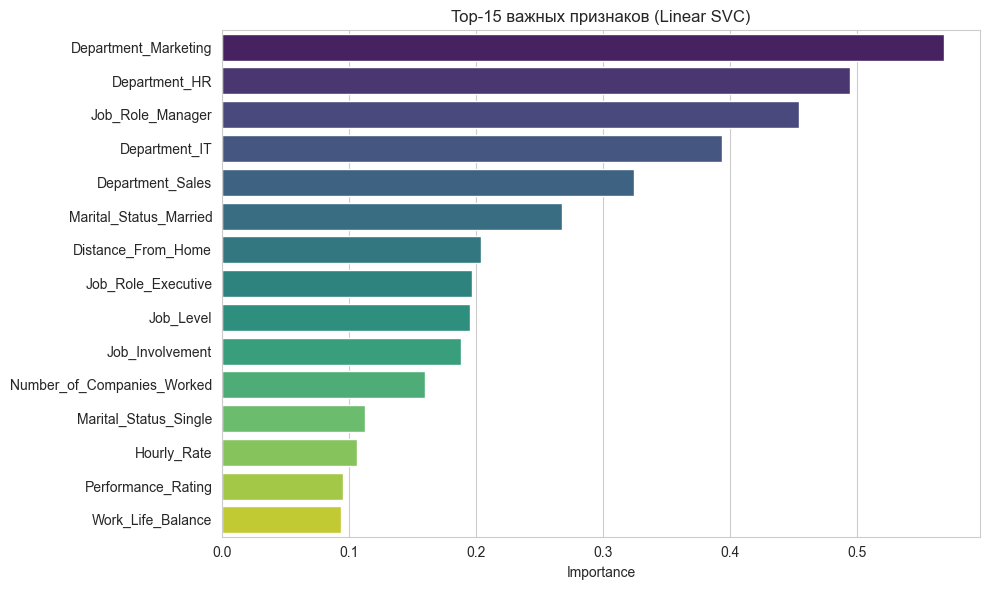

In [27]:
# Выбираем модель с максимальным F1 среди всех (можно заменить на конкретную)
best_model_name = final_table.sort_values('F1 (Yes)', ascending=False).iloc[0]['Model']
print('Лучшая модель для анализа важности:', best_model_name)

# Найдём обученную модель
if 'tuned' in best_model_name:
    best_model = tuned_models[best_model_name]
else:
    best_model = models[best_model_name]

feature_names = X_train.columns.tolist()
plot_feature_importance(best_model, feature_names, top_n=15, title=f'Top-15 важных признаков ({best_model_name})')

### Ансамбль (VotingClassifier)
Объединим несколько лучших моделей.

In [28]:
from sklearn.ensemble import VotingClassifier

# Возьмём топ-3 модели по F1 (можно взять оригинальные, не tuned)
top3_names = results_df.sort_values('F1 (Yes)', ascending=False).head(3)['Model'].values
estimators = [(name, models[name]) for name in top3_names]

voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

ensemble_results = evaluate_models_extended({'Ensemble (Voting)': voting_clf}, X_test, y_test)
ensemble_results['Experiment'] = 'Ensemble'

# Добавляем в общую таблицу
final_table = pd.concat([final_table, ensemble_results], ignore_index=True)
print('Финальная таблица с ансамблем:')
final_table[['Experiment', 'Model', 'Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'F1 (Yes)', 'ROC-AUC', 'PR-AUC']].round(4)

KeyboardInterrupt: 

### Сохранение лучшей модели
Выбираем модель с наивысшим F1 (Yes) из всей таблицы и сохраняем.

In [ ]:
final_best = final_table.sort_values('F1 (Yes)', ascending=False).iloc[0]
print('Финальная лучшая модель:', final_best['Model'], 'с F1 =', round(final_best['F1 (Yes)'], 4))

# Определяем объект модели
if final_best['Model'] in models:
    model_to_save = models[final_best['Model']]
elif final_best['Model'] in tuned_models:
    model_to_save = tuned_models[final_best['Model']]
else:
    model_to_save = voting_clf  # ансамбль

save_model(model_to_save, 'best_model_cp2.pkl')
print('Лучшая модель сохранена.')

Финальная лучшая модель: Linear SVC с F1 = 0.2906
Модель сохранена как best_model_cp2.pkl
Лучшая модель сохранена.


## Выводы
- Протестированы 6 моделей. Лучший результат у **Linear SVC** (F1=0.29, Recall=0.52, Precision=0.20).
- Линейные модели (Logistic Regression, Linear SVC) справились лучше нелинейных: Random Forest не обнаружил ни одного увольнения, XGBoost и KNN показали низкий Recall.  
- Ансамбль (Voting) не дал прироста (F1=0.21).
- Причина скромных метрик – слабые корреляции признаков с целевой переменной, выявленные ещё на EDA.
- Финальная модель (Linear SVC) пригодна для выделения группы риска (находит 52% уволившихся), но даёт много ложных тревог.
- Дальнейшие улучшения: генерация новых признаков, подбор порога вероятности, расширенный тюнинг гиперпараметров.